# BLAES Single-Unit Analyses

<p>
This notebook contains code for... 
</p>

> Author:    Justin Campbell    
> Contact:   justin.campbell@hsc.utah.edu   
> Version:   08/12/2023
---

## Setup Notebook

In [1]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import Blackrock Python Utilities
sys.path.append('/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Code/Misc/Blacrock-Python-Utilities')
import brpylib

In [2]:
%config InlineBackend.figure_format='retina'

### Define Helper Functions
- `loadSpikes`: Takes the path to a .nev file, loads the data, finds valid units, and returns two variables (i.e., `spikeDF`, `waveforms`)
- `plotUnitWaveforms`: Take a channel # as input, plots the average waveform (±SD) for each unit, display waveform counts

In [3]:
def loadNEV(nev_path):
    
    # Open .nev file
    nev_file = brpylib.NevFile(nev_path)
    
    # Extract data
    nev_data = nev_file.getdata()['spike_events']
    
    # Close .nev file
    nev_file.close()
    
    # Extract waveforms
    waveforms = nev_data['Waveforms']
    
    # Convert spike events to pd.DataFrame
    spikes = nev_data.copy()
    spikes.pop('Waveforms', None)
    spikeDF = pd.DataFrame.from_dict(spikes)
    
    # Define valid unit labels
    valid_unit_labels = np.arange(1,17) # 0 = unclassified, 255 = noise, 1-16 = valid units
    spikeDF = spikeDF[spikeDF['Unit'].isin(valid_unit_labels)]
    valid_unit_idxs = spikeDF.index.values
    waveforms = waveforms[valid_unit_idxs]
    
    # Reindex
    spikeDF.reset_index(drop = True, inplace = True)
    
    return spikeDF, waveforms

In [4]:
def plotUnitWaveforms(chan, saveas = None):
    
    # Parset spikeDF for chan data
    unitDF = spikeDF[spikeDF['Channel'] == chan]
    unit_idxs = unitDF.index.values
    
    # Parse waveforms using unit indices
    unit_waveforms = pd.DataFrame(waveforms[unit_idxs])
    
    # Add unit labels
    unit_waveforms['Unit'] = unitDF['Unit'].reset_index(drop=True)
    
    # Track waveform counts for legend
    waveform_counts = unitDF['Unit'].value_counts().values.tolist()
    waveform_counts = [str(x) for x in waveform_counts]
    
    # Melt DataFrame for plotting in Seaborn
    unit_waveforms = unit_waveforms.melt(id_vars = ['Unit'], var_name = 'Time', value_name = 'Voltage')
    
    # Figure parameters
    fig, ax = plt.subplots(1, 1, figsize = (5,2.5))
    
    # Adjust time (samples -> ms)
    unit_waveforms['Time'] = (unit_waveforms['Time'] / fs) * 1000
    
    # Plot average waveform ± SD (shaded)
    sns.lineplot(x = 'Time', y = 'Voltage', hue = 'Unit', data = unit_waveforms, palette = 'Set2', linewidth = 2, errorbar = 'sd')
    
    # Figure aeshetics
    plt.xlim([0,1.5])
    plt.xticks([0, 0.5, 1, 1.5])
    plt.xlabel('Time (ms)', fontsize = 'x-large')
    plt.yticks([-500, -250, 0, 250])
    plt.ylabel('Voltage ($\mu$V)', fontsize = 'x-large')
    plt.title('Chan: %s ' %str(chan))
    legend_handles, _= ax.get_legend_handles_labels()
    ax.legend(legend_handles, waveform_counts, title = '# WFs', loc = 'lower right', fontsize = 'x-small', title_fontsize = 'x-small')
    sns.despine(top = True, right = True)
    
    # Export figure
    if saveas is not None:
        if not os.path.exists(os.path.join(save_path, 'Units')):
            os.mkdir(os.path.join(save_path, 'Units'))
        plt.savefig(os.path.join(save_path, 'Units', saveas), dpi = 1200, bbox_inches = 'tight')
    
plt.show()

## Load & Process Data

In [5]:
file_name = 'BLAES_study_UIC202202001_rethresholdedJC021523_sortedRC032223.nev'

In [6]:
# Data parameters
pID = file_name.split('_')[2]
fs = 30000

# Paths
proj_path = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/'
data_path = os.path.join(proj_path, 'Data')
nev_path = os.path.join(data_path, file_name)
save_path = os.path.join(proj_path, 'Results', pID)

# Create save_path if it doesn't exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [7]:
%%capture
spikeDF, waveforms = loadNEV(nev_path)

## Summarize Dataset

In [10]:
# Group spikeDF by Channel and Unit, count the number of waveforms for each unit
summary_DF = spikeDF.groupby(['Channel', 'Unit']).count()
summary_DF.rename(columns={'TimeStamps': 'Waveforms'}, inplace=True)

# Export summary_DF to csv
summary_DF.to_csv(os.path.join(save_path, 'WaveformCounts.csv'))

# Display features
print('Session: %s' %pID)
print('# Channels w/ Units: %s' %len(spikeDF['Channel'].unique()))
print('# Units Detected: %s' %str(summary_DF.shape[0]))
print('# Waveforms (Mean ± SD): %.1f ± %.1f' %(summary_DF['Waveforms'].mean(), summary_DF['Waveforms'].std()))
summary_DF

Session: UIC202202001
# Channels w/ Units: 11
# Units Detected: 13
# Waveforms (Mean ± SD): 1507.5 ± 1639.7


Waveforms
Channel Unit           
98      1           118
100     1          2989
        2          1407
101     1           321
102     1           581
104     1           219
107     1          1494
108     1           189
109     1          5221
110     1          1038
111     1          1623
        2           264
128     1          4133

## Visualize Waveforms

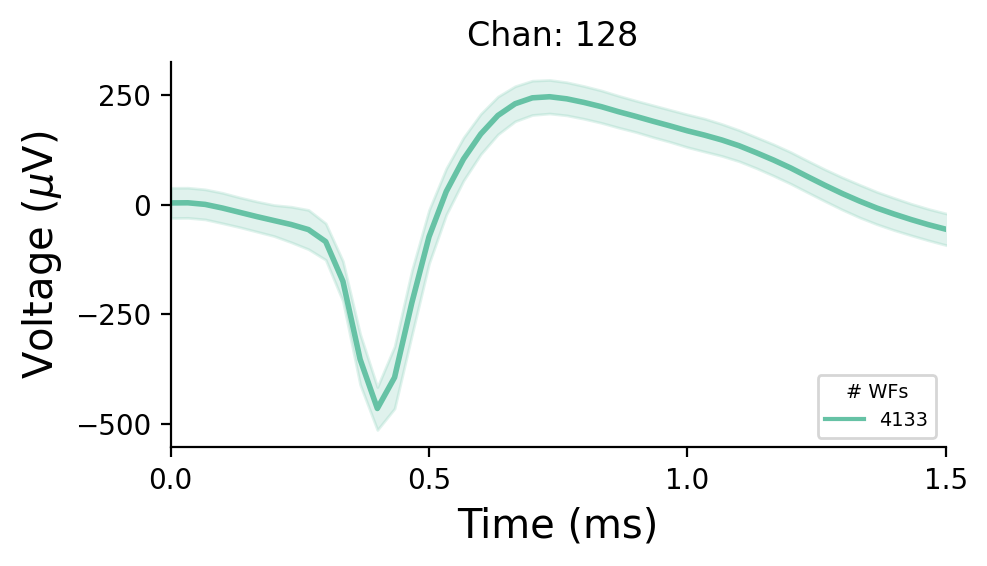

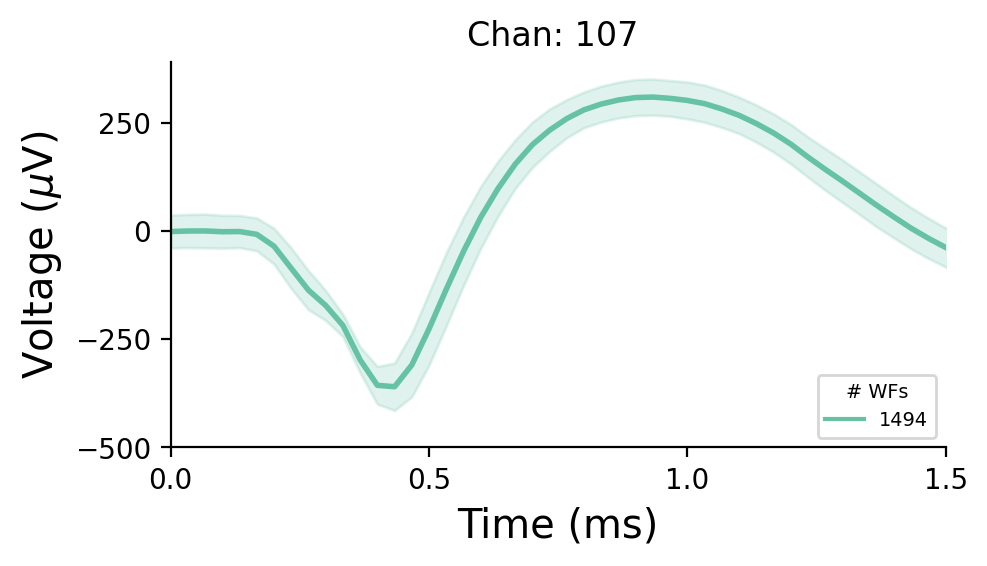

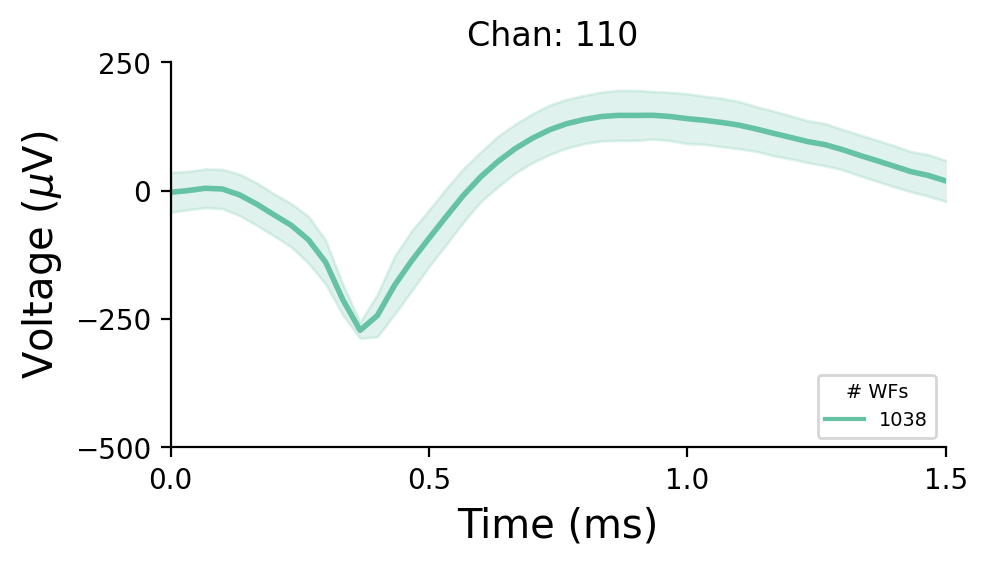

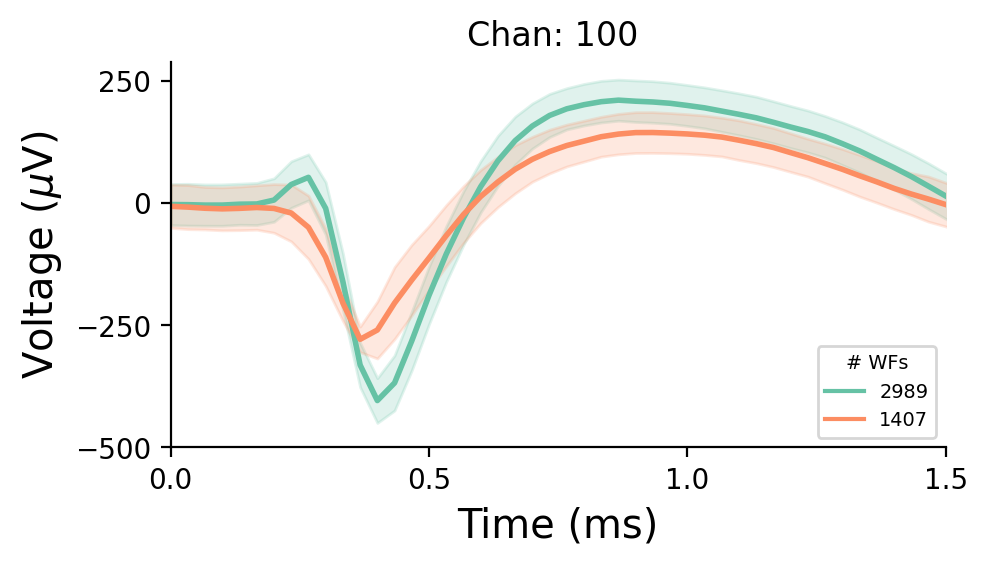

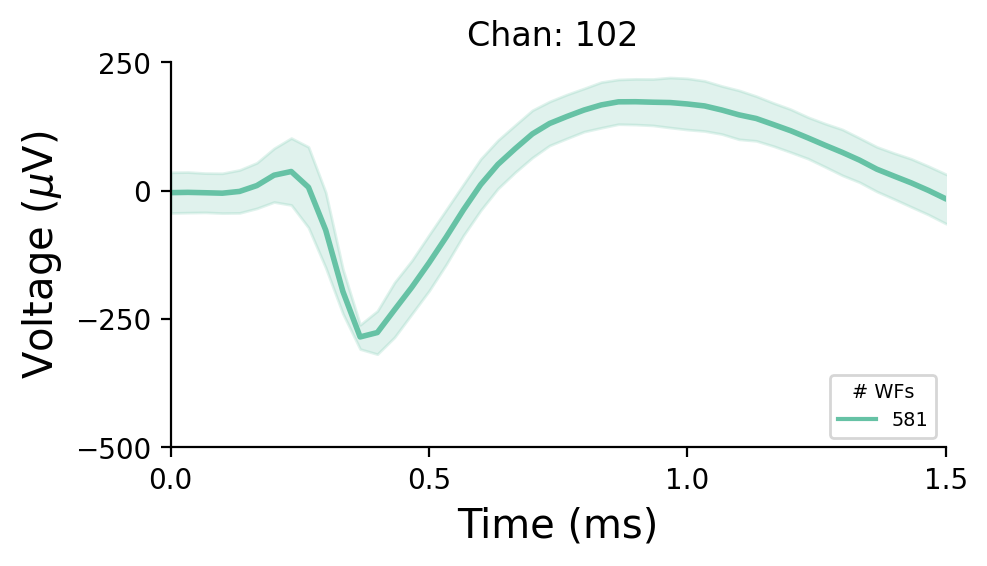

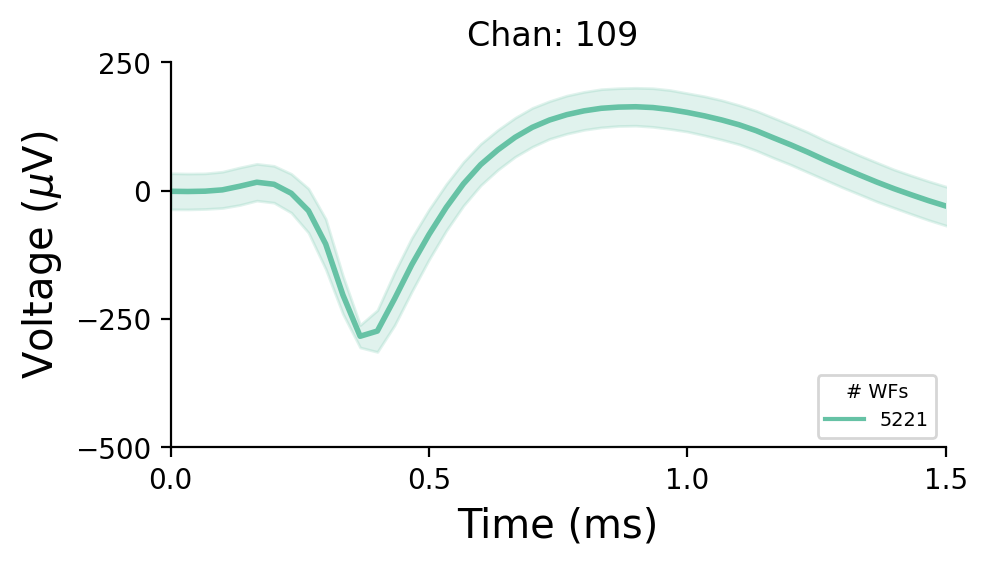

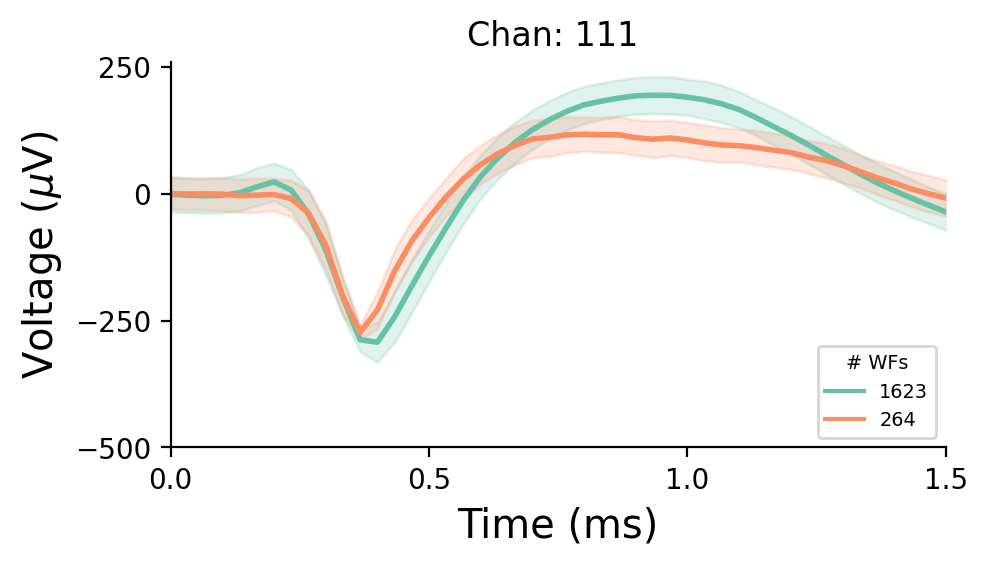

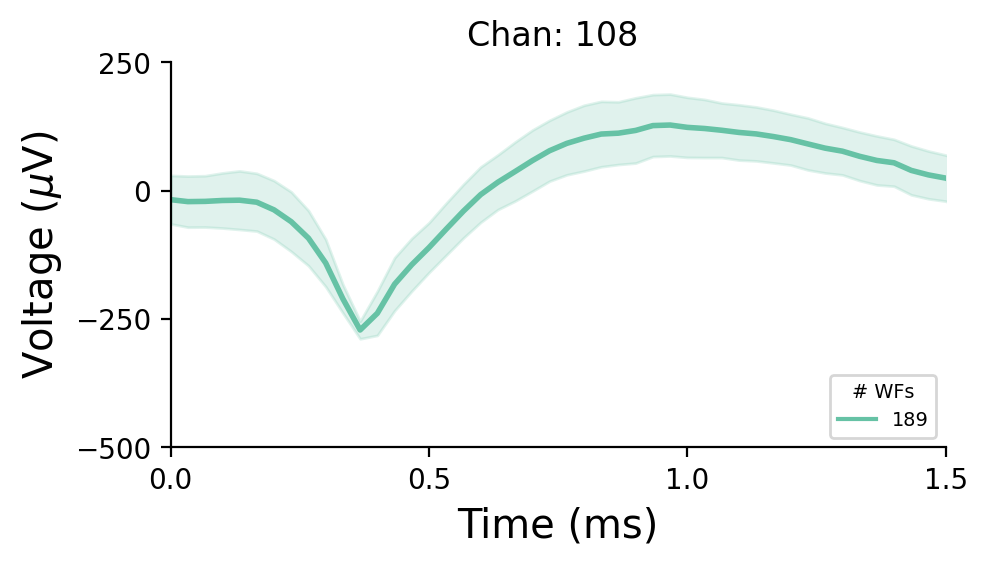

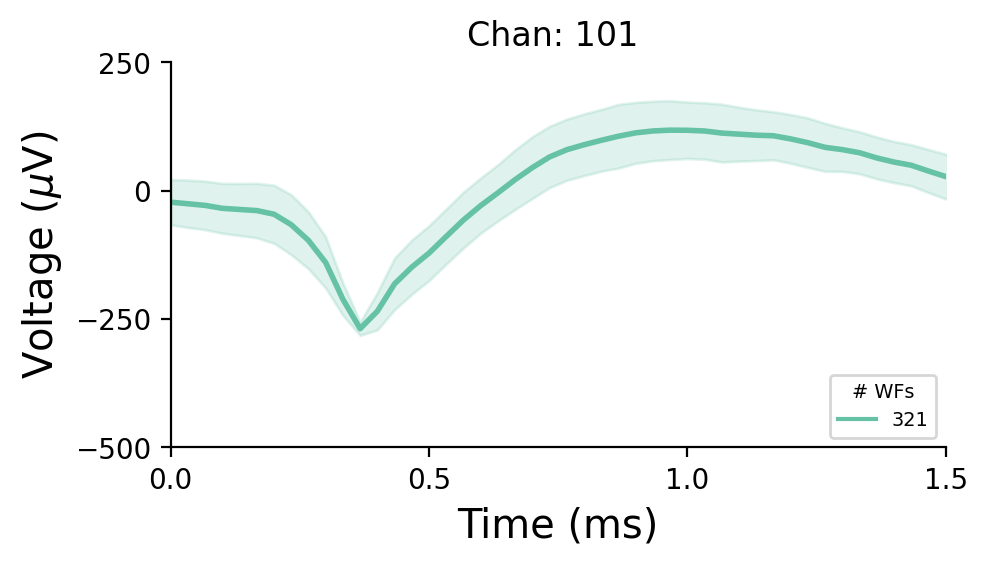

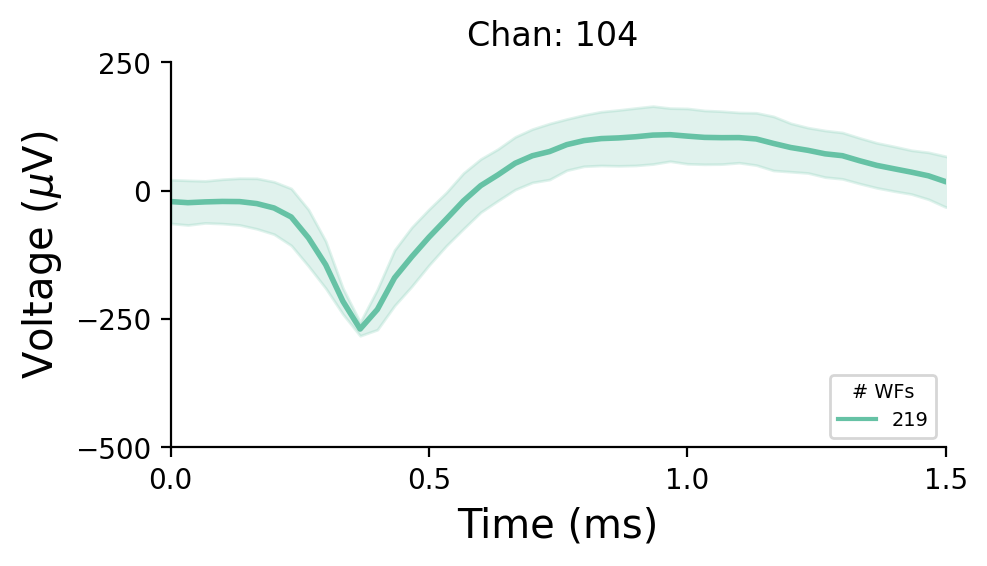

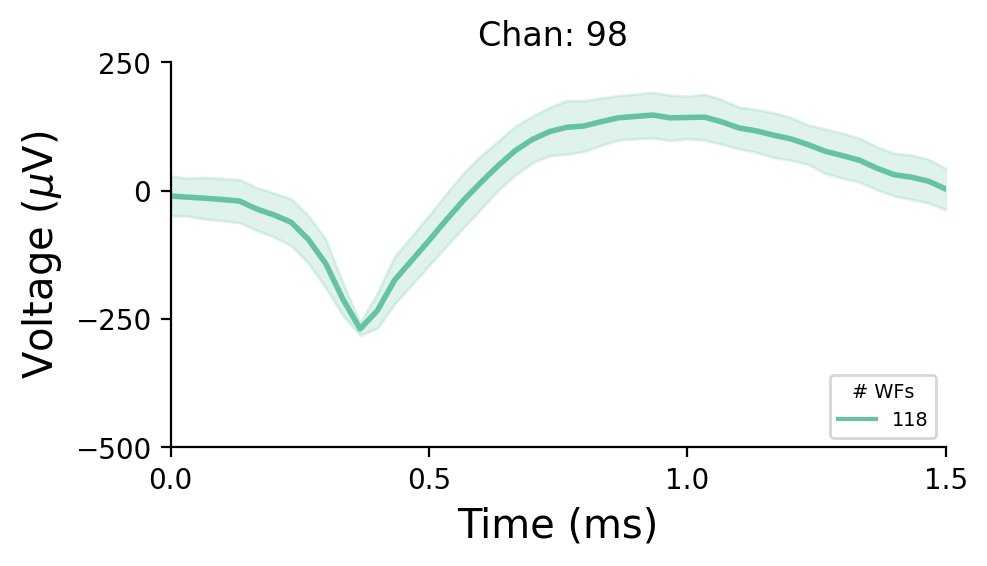

In [9]:
# Plot unit waveforms for each channel
for chan in spikeDF['Channel'].unique():
    plotUnitWaveforms(chan = chan, saveas = ('Chan' + str(chan) + '_units.png')) # ChanXXX_units.png